# ML Driven MOF PFAS Adsorbent Discovery

### Set-up

In [1]:
import sys
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting data
import os
#import re
np.random.seed(42)

In [47]:
from sklearn.svm import OneClassSVM, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA


In [33]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_with_ols(x, y, labels, poly_deg=1, x_label=None, y_label=None, title=None):
    """
    Create a scatter plot of x vs y with an OLS polynomial fit and R-squared.
    
    Parameters
    ----------
    x, y : array-like
        Input feature arrays of equal length.
    poly_deg : int, optional (default=1)
        Polynomial degree for OLS fit (1 = linear, up to 3).
    x_label, y_label : str, optional
        Axis labels.
    title : str, optional
        Plot title.
    """
    if poly_deg < 1 or poly_deg > 3:
        raise ValueError("poly_deg must be 1, 2, or 3")

    x = np.asarray(x)
    y = np.asarray(y)

    # Polynomial OLS fit
    coeffs = np.polyfit(x, y, poly_deg)
    poly = np.poly1d(coeffs)

    # Predictions (sorted for smooth curve)
    x_sorted = np.sort(x)
    y_pred_sorted = poly(x_sorted)
    y_pred = poly(x)

    # R-squared
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot

    # Plot
    plt.figure()
    # Map labels to colors
    colors = ['red' if l == 0 else 'blue' for l in labels]

    plt.scatter(x, y, c=colors)
#    plt.scatter(x, y)
    plt.plot(x_sorted, y_pred_sorted)
    
    plt.xlabel(x_label if x_label else "X")
    plt.ylabel(y_label if y_label else "Y")
    plt.title(title if title else f"Scatter Plot with Degree-{poly_deg} OLS Fit")

    plt.text(
        0.05, 0.95,
        f"Degree = {poly_deg}\n$R^2 = {r_squared:.3f}$",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.show()

    return r_squared


In [13]:
folder_path = r'../data/'
dfs = {}
file_start = 'Descriptors-'
file_end = '-TwoClass-v1.csv'

for filename in os.listdir(folder_path):
    #print(filename)
    if filename.startswith(file_start) and filename.endswith(file_end):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)

        pfas_name = filename.removeprefix(file_start).removesuffix(file_end)
        # pfas_name = filename.replace('Descriptors-', '')
        # pfas_name = pfas_name.replace('.csv', '')
        print(pfas_name)
        dfs[pfas_name] = df

PFOA


In [15]:
for filename in os.listdir(folder_path):
    #print(filename)
    if filename.startswith('Test') and filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        mof_name = filename.removeprefix('Test_').removesuffix('.csv')
        print(mof_name)
        dfs[mof_name] = df

coremof
coremof_FSR
coremof_Ion
coremof_NCR
coremof_occupancy


In [17]:
dfs.keys()


dict_keys(['PFOA', 'coremof', 'coremof_FSR', 'coremof_Ion', 'coremof_NCR', 'coremof_occupancy'])

### Adsorbent Features

The following adsorbent features are used:

- **Density**: Framework density of the MOF, reflecting how compact or open the porous structure is.
- **PLD (Pore Limiting Diameter)**: Diameter of the largest spherical probe that can pass through the narrowest pore window, indicating if PFAS can **enter** pore.
- **LCD (Largest Cavity Diameter)**: Diameter of the largest spherical cavity within the framework, indicating if the PFAS can **fit** comfortably.
- **GSA (Geometric Surface Area)**: Total internal surface area of the framework accessible to a probe molecule, representing available adsorption surface.
- **Void Fraction**: Fraction of the unit cell volume that is empty space, serving as a measure of porosity.
- **Pore Volume**: Total accessible pore volume per unit mass of the framework, serving as a proxy for adsorption capacity.


# PART-A: Data Filtering

In [19]:
numeric_df = dfs['PFOA'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

,min,max,mean,range
Density,0.175207,2.02273,1.084413,1.847523
PLD,0.621250,28.35169,6.905572,27.730440
LCD,1.497060,34.15409,12.637521,32.657030
GSA,2178.080000,5397.31000,3895.514571,3219.230000
Void_Fraction,0.186605,0.93080,0.591048,0.744195
Pore_Volume,0.099996,5.31257,0.910946,5.212574
Label,0.000000,1.00000,0.714286,1.000000


In [ ]:
numeric_df = dfs['PFOA'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

In [ ]:
numeric_df = dfs['coremof_FSR'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

We see a few relationships between features:

In [21]:
#Set PFAS type
PFAS = "PFOA" #"coremof"

In [27]:
dfs[PFAS]['Label']

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    1
31    1
32    0
33    0
34    0
Name: Label, dtype: int64

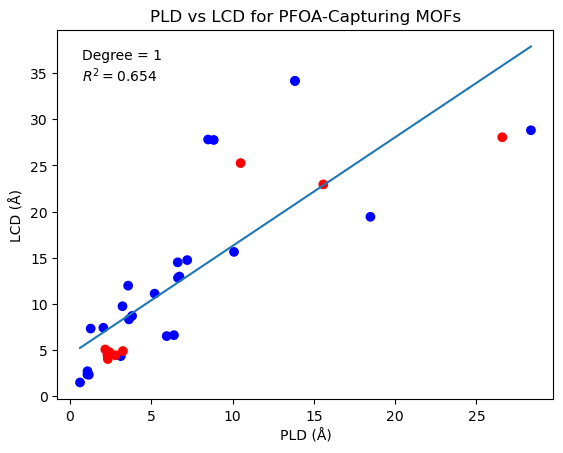

In [35]:
feature1 = "PLD"
feature2 = "LCD"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 1, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")


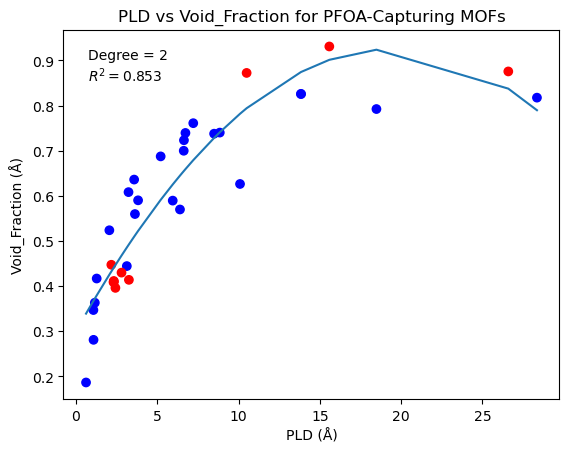

In [37]:
feature1 = "PLD"
feature2 = "Void_Fraction"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")


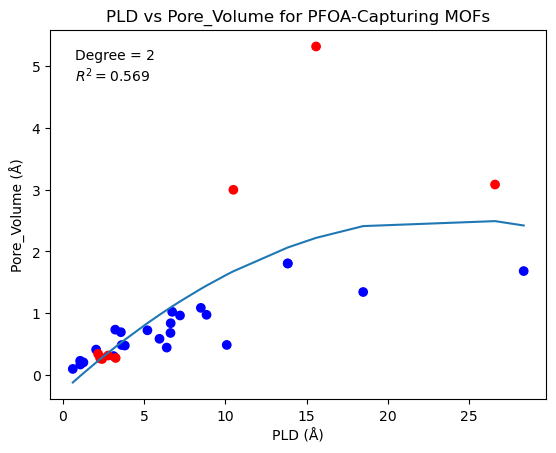

In [39]:
feature1 = "PLD"
feature2 = "Pore_Volume"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")

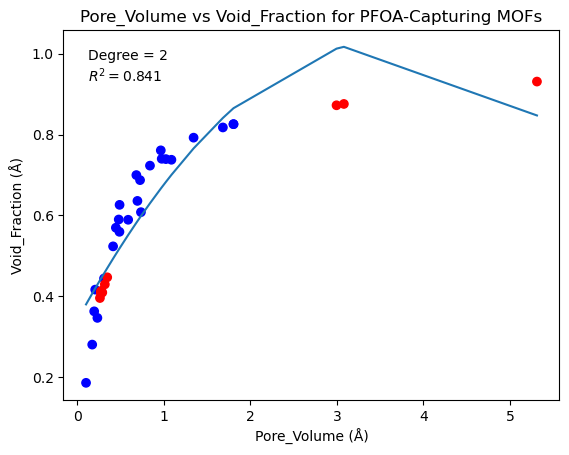

In [41]:
feature1 = "Pore_Volume"
feature2 = "Void_Fraction"

r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")

### Key Takeaways




# Two Class SVM

In [53]:
# Core descriptor set
core_features = [
    "PLD",
    "LCD",
    "GSA",
    "Void_Fraction",
    "Pore_Volume",
    # "Density",  # uncomment later for sensitivity analysis
]

# Select PFAS dataset
df = dfs["PFOA"].copy()

# Extract feature matrix
X = df[core_features].values
y = df["Label"]


In [55]:
svc = Pipeline(steps=[("scaler", StandardScaler()),
                      ("svc", SVC(
                          kernel="rbf",
                          C=1.0, #penalisation parameter for classification error
                          gamma="scale",
                          class_weight="balanced" #useful for small imbalanced data
                      ))])

svc.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(class_weight='balanced'))])

In [ ]:
ocsv

In [ ]:
ocsvm.fit(X)

In [ ]:
rho = -ocsvm.named_steps["ocsvm"].intercept_[0]
max_possible_score = 1 - rho

print("rho:", rho)
print("Theoretical max score:", max_possible_score)

In [ ]:
# Decision function: higher = more confidently inside the region
scores = ocsvm.decision_function(X)

# Binary labels: +1 = inlier, -1 = outlier
labels = ocsvm.predict(X)

df_results = df.copy()
df_results["ocsvm_score"] = scores
df_results["ocsvm_label"] = labels


In [ ]:
df_results.sort_values("ocsvm_score", ascending=False)

### Results interpretation:
- only the relative scores are important
- can not iterpret the absoute values (this is not parametric)

### Training with Density

In [ ]:
core_plus_density_features  = core_features + ["Density"]
X_density = df[core_plus_density_features].values

ocsvm_density = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ocsvm", OneClassSVM(
            kernel="rbf",
            nu=nu_hypP,
            gamma="scale"
        ))
    ]
)

ocsvm_density.fit(X_density)

df_results["ocsvm_score_with_density"] = ocsvm_density.decision_function(X_density)


In [ ]:
df_results.sort_values("ocsvm_score")


### Plotting training
- Plot the exact OC-SVM boundary is *impossible* because it lives in 5-6 dimensional (features) space further increased by the kernel induced space.

So the objective becomes to "Visualize how points relate to the OC-SVM decision function in a meaningful 2D projection":

Explanation.

We have two optoins:
  - visualise with first 2 pca, or
  - Decision boundaries were visualized by evaluating the OC-SVM on 2D slices of the scaled descriptor space, constructed by varying selected feature pairs while fixing all remaining descriptors at their mean values.”


In [ ]:
scaler = ocsvm.named_steps["scaler"]
svm = ocsvm.named_steps["ocsvm"]
nu = ocsvm.named_steps["ocsvm"].nu
X_scaled = scaler.transform(X)


In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca1 = X_pca[:, 0]
X_pca2 = X_pca[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)


In [ ]:
type(df_results['PLD'].to_numpy())
#type(X_feature)

In [ ]:
X_scaled

In [ ]:
#Select Plot space
plot_space = 1 # plot_space: 1 --> PCA plo; 2--> original features
feat_x = 0  # e.g. PLD
feat_y = 1  # e.g. LCD

if plot_space == 1:
    X_feature = X_pca1
    Y_feature = X_pca2
else: 
    X_feature = X_scaled[:, feat_x]
    Y_feature = X_scaled[:, feat_y]
    


In [ ]:
#Build a grid in selected space

x_min, x_max = X_feature.min() - 1, X_feature.max() + 1
y_min, y_max = Y_feature.min() - 1, Y_feature.max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

#grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_2d = np.c_[xx.ravel(), yy.ravel()]

In [ ]:
# Back to scaled feature space
#grid_scaled = pca.inverse_transform(grid__2d)
# Back to scaled feature space (version that allows to plot original features)
if plot_space == 1:
    grid_scaled = pca.inverse_transform(grid_2d)
else:
    # Start from mean of scaled data: 
    grid_scaled = np.tile(X_scaled.mean(axis=0), (grid_2d.shape[0], 1)) 

    # Insert grid values into the selected feature dimensions
    grid_scaled[:, feat_x] = grid_2d[:, 0]
    grid_scaled[:, feat_y] = grid_2d[:, 1]

# Evaluate OC-SVM decision function
Z = svm.decision_function(grid_scaled)
Z = Z.reshape(xx.shape)


### Plot Training

In [ ]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# Plot points
labels = ocsvm.predict(X)
plt.scatter(
    X_feature, Y_feature,
    c=labels, cmap="coolwarm", edgecolors="k"
)

# Annotate MOFs
for i, name in enumerate(df["Name"]):
    plt.text(X_feature[i], Y_feature[i], name, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"OC-SVM PFAS–MOF Region (PCA projection){nu}")

plt.savefig(rf"..\Notebooks\OCSVM-Region-nu{nu}.png", 
            format='png', 
            bbox_inches='tight', 
            transparent=True,
            pad_inches=0)
plt.show()


### Some more thoughts:

- Material Identity discovery vs material property prediciton
- i.e. we are answering "Does this look like the kind of MOFs that work"? Not anwering "How well will this MOF work".

In [ ]:
X_pca

# Testing

#### Test: Inference


- *Output Score Intepretation*: A signed geometric margin measuring how strongly a structure belongs to the learned PFAS-compatible descriptor region.
$$
f(x) = \sum_{i=1}^{n} \alpha_i \, K(x_i, x\prime) - \rho
$$
where:
$x_i$ are known PFAS MOF descriptors, (one per training sample - not feature - nice feature, see 'Representer Theorem').
$x\prime$ is the candidate MOF descriptor to be evaluated.
 
- *Parameter Intepretation*: An upper bound on the fraction of training points allowed to be outside (small 'nu' --> model tries to include all point in training --> large permissive boundary).
- Standardisation centres all observation around mean with a 'few' std devs of data on either side. While this does not mean distance between two points is zero, it does imply "small" distance scores for points within the learned region. 

- Note, the kernel used is the RBF kernel that allows non-linear regions:
$$
K(x, x\prime) = \exp\left(-\gamma \|x - x\prime\|^2\right)
$$

dfs.keys():
dict_keys(['PFOA', 'PFOS', 'coremof', 'coremof_FSR', 'coremof_Ion', 'coremof_NCR', 'coremof_occupancy'])


In [ ]:
# Extract and scale the Test set
test_set = "coremof_occupancy"
scaler = ocsvm.named_steps["scaler"]
X_test_core = dfs[test_set][core_features].values
X_test_core_scaled = scaler.transform(X_test_core)

# X_coremof_core_plus_density = dfs["coremof"][core_plus_density_features].values
# X_coremof_core_plus_density_scaled = scaler_core_plus_density.transform(
#     X_coremof_core_plus_density
# )

# Get anomaly scores
scores_test = ocsvm.decision_function(X_test_core)

# scores_core_plus_density = model_core_plus_density.decision_function(
#     X_coremof_core_plus_density_scaled
# )
 
# Get binary in/out classification
labels_test = ocsvm.predict(X_test_core)
# labels_core_plus_density = model_core_plus_density.predict(
#     X_coremof_core_plus_density_scaled
# )


In [ ]:
dfs[test_set][core_features]

In [ ]:
dfs[test_set]["score_test"] = scores_test
dfs[test_set]["label_test"] = labels_test

# dfs["coremof"]["score_core_plus_density"] = scores_core_plus_density
# dfs["coremof"]["label_core_plus_density"] = labels_core_plus_density

In [ ]:
results_sorted = dfs[test_set].sort_values("score_test", ascending=False)
results_sorted

In [ ]:
output_folder = r'..\results'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
file_path = os.path.join(output_folder, f"{test_set}_results_nu{nu_hypP}.csv")

results_sorted.to_csv(file_path, index=False)

#### Testing: comparing models
- Important ..

#### Testing: Plotting
- Important to remember not to refit PCA on coremof

In [ ]:
# Use the SAME scaler from pipeline
scaler = ocsvm.named_steps["scaler"]

X_test_scaled = scaler.transform(X_test_core)

# Project into PCA space
X_test_pca = pca.transform(X_test_scaled)
    
X_test_pca1 = X_test_pca[:, 0]
X_test_pca2 = X_test_pca[:, 1]

In [ ]:
# # Get labels for coremof
# labels_core = ocsvm.predict(X_coremof_core)

# # Overlay coremof points
# plt.scatter(
#     X_coremof_pca1,
#     X_coremof_pca2,
#     c=labels_core,
#     cmap="coolwarm",
#     marker="x",
#     s=40,
#     alpha=0.7
# )


In [ ]:
# Training data
plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# plt.scatter(X_feature, Y_feature,
#             c=labels,
#             cmap="coolwarm",
#             edgecolors="k",
#             s=80,
#             label="Training MOFs")

# Coremof data
plt.scatter(X_test_pca1,
            X_test_pca2,
            c=labels_core,
            cmap="coolwarm",
            marker="o",
            s=40,
            alpha=0.7,
            label=test_set)

plt.legend()
plt.title(f"OC-SVM Test Region (PCA projection){nu}")
# plt.savefig(rf"..\Notebooks\OCSVM-Test-nu{nu}.png", 
#             format='png', 
#             bbox_inches='tight', 
#             transparent=True,
#             pad_inches=0)
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# Plot points
labels = ocsvm.predict(X)
plt.scatter(
    X_feature, Y_feature,
    c=labels, cmap="coolwarm", edgecolors="k"
)

# Annotate MOFs
for i, name in enumerate(df["Name"]):
    plt.text(X_feature[i], Y_feature[i], name, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"OC-SVM PFAS–MOF Region (PCA projection){nu}")

# plt.savefig(rf"..\Notebooks\OCSVM-Region-nu{nu}.png", 
#             format='png', 
#             bbox_inches='tight', 
#             transparent=True,
#             pad_inches=0)
plt.show()

In [ ]:
result_df_15